In [1]:
import pandas as pd

path = 'C:/Unicamp/mestrado/simulacoes/RPS-python/RPS-POO/outputs/sensibilidade/vizinhosY_e_B/'
prob_ter_3_estrategias = pd.read_csv(path + 'prob_ter_3_estrategias_todas.csv')
#print(prob_ter_3_estrategias)
#print(prob_ter_3_estrategias)

manutencao_medio = pd.read_csv(path + 'manutencao_media_todas.csv')
print(manutencao_medio[manutencao_medio['y'] == 1])

prop_estrategias_mantidas = pd.read_csv(path + 'prop_estrategias_mantidas_todas.csv')
#print(prop_estrategias_mantidas)


     y   b  media_estrategias_mantidas  std_estrategias_mantidas
0    1   1                        2.00                  0.000000
1    1   2                        2.00                  0.000000
2    1   3                        2.03                  0.171447
3    1   4                        2.95                  0.219043
4    1   5                        3.00                  0.000000
25   1   6                        3.00                  0.000000
26   1   7                        3.00                  0.000000
27   1   8                        3.00                  0.000000
28   1   9                        3.00                  0.000000
29   1  10                        3.00                  0.000000
50   1  11                        2.75                  0.479372
51   1  12                        1.60                  0.828775
52   1  13                        1.05                  0.297294
53   1  14                        1.00                  0.000000
54   1  15               

In [2]:
# ...existing code...
def dedupe_identicos(df, key_cols=['y','b']):
    total_before = len(df)
    groups = df.groupby(key_cols)
    keep_idx = []
    dup_groups = 0
    kept_from_dups = 0
    for name, g in groups:
        if len(g) == 1:
            keep_idx.append(g.index[0])
            continue
        dup_groups += 1
        other_cols = [c for c in df.columns if c not in key_cols]
        nunique = g[other_cols].nunique(dropna=False)
        if (nunique == 1).all():  # todas as outras colunas têm valor igual no grupo
            keep_idx.append(g.index[0])  # mantém apenas a primeira linha do grupo
            kept_from_dups += 1
        else:
            keep_idx.extend(g.index.tolist())  # mantém todas (há diferenças)
    result = df.loc[keep_idx].reset_index(drop=True)
    print(f"linhas antes: {total_before}, grupos (y,b) duplicados: {dup_groups}, grupos consolidados: {kept_from_dups}, linhas depois: {len(result)}")
    return result

manutencao_medio_dedupe = dedupe_identicos(manutencao_medio, ['y','b'])
prob_ter_3_estrategias_dedupe = dedupe_identicos(prob_ter_3_estrategias, ['y','b'])
prop_estrategias_mantidas_dedupe = dedupe_identicos(prop_estrategias_mantidas, ['y','b'])

# opcional: sobrescrever os originais
# manutencao_medio = manutencao_medio_dedupe
# prob_ter_3_estrategias = prob_ter_3_estrategias_dedupe
# prop_estrategias_mantidas = prop_estrategias_mantidas_dedupe

# opcional: salvar
# manutencao_medio_dedupe.to_csv(path + 'manutencao_media_todas_dedupe.csv', index=False)
# ...existing code...

linhas antes: 1936, grupos (y,b) duplicados: 164, grupos consolidados: 164, linhas depois: 1764
linhas antes: 1936, grupos (y,b) duplicados: 164, grupos consolidados: 164, linhas depois: 1764
linhas antes: 1936, grupos (y,b) duplicados: 164, grupos consolidados: 164, linhas depois: 1764


C:\Users\nicko\AppData\Local\Temp\ipykernel_26896\3385900998.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="O = 8")


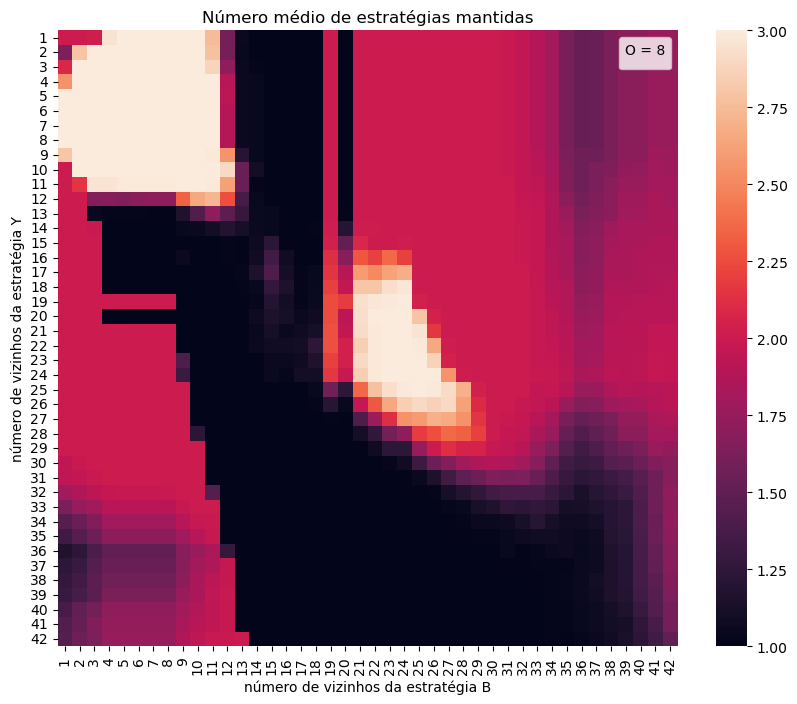

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Heatmap (média de estratégias vivas por (y,b)) ---
heatmap_data = manutencao_medio_dedupe.pivot(index="y", columns="b", values="media_estrategias_mantidas")

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data, annot=False, fmt=".2f", cmap="rocket")
plt.title("Número médio de estratégias mantidas")
plt.ylabel("número de vizinhos da estratégia Y")
plt.xlabel("número de vizinhos da estratégia B")
plt.legend(title="O = 8")
plt.savefig(path + 'manutencao_estrategias_media_heatmap.png')
plt.show()

C:\Users\nicko\AppData\Local\Temp\ipykernel_26896\2390126800.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="O = 8")


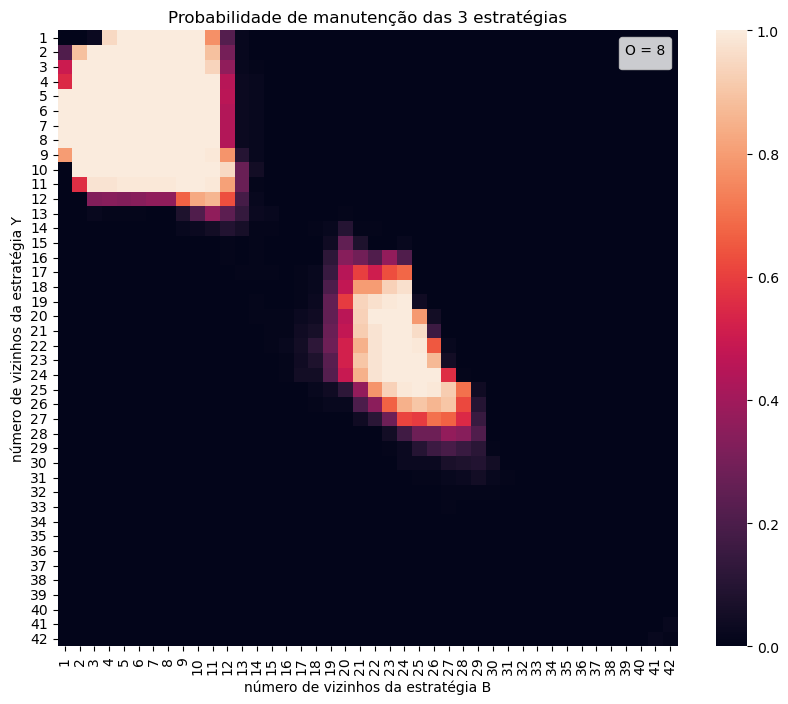

In [4]:
# --- Heatmap (probabilidade de ter 3 estratégias vivas por (y,b)) ---
heatmap_data_3_strat = prob_ter_3_estrategias_dedupe.pivot(index="y", columns="b", values="prob_ter_3_estrategias")    

plt.figure(figsize=(10,8))
sns.heatmap(heatmap_data_3_strat, annot=False, fmt=".2f", cmap="rocket")
plt.title("Probabilidade de manutenção das 3 estratégias")
plt.ylabel("número de vizinhos da estratégia Y")
plt.xlabel("número de vizinhos da estratégia B")
plt.legend(title="O = 8")
plt.savefig(path + 'prob_ter_3_estrategias_heatmap.png')
plt.show()

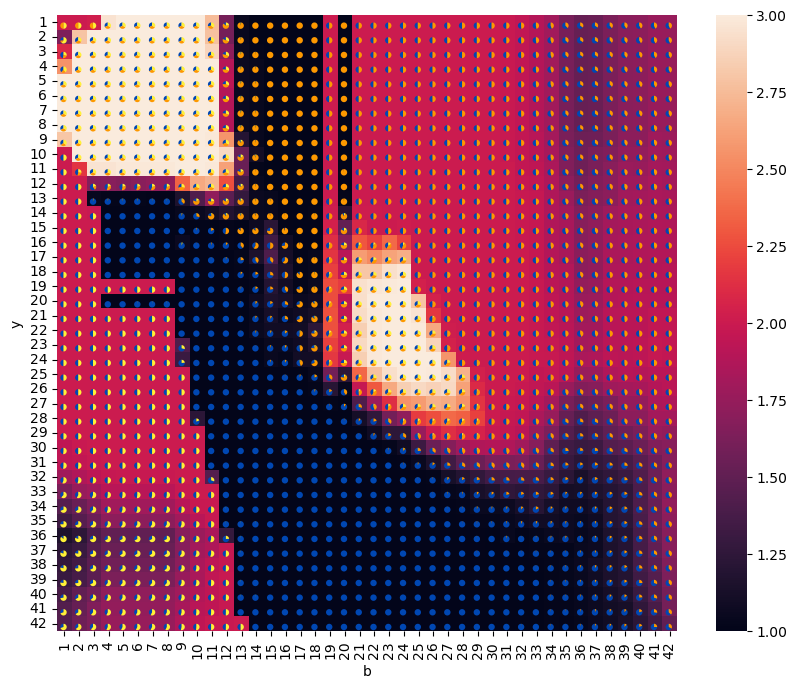

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Heatmap de fundo
heatmap_data = manutencao_medio_dedupe.pivot(index="y", columns="b", values="media_estrategias_mantidas")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(heatmap_data, ax=ax, cmap="rocket", cbar=True, annot=False)

# Sobrepor gráficos de pizza
for _, row in prop_estrategias_mantidas_dedupe.iterrows():
    y = row['y']
    b = row['b']
    sizes = [row['prop_B_mantida'], row['prop_O_mantida'], row['prop_Y_mantida']]
    # Coordenadas do centro da célula
    x = b - 0.9
    y_coord = y + 1
    # Cria um eixo menor para a pizza
    pie_ax = fig.add_axes([ax.get_position().x0 + x/heatmap_data.shape[1]*ax.get_position().width,
                           ax.get_position().y0 + (heatmap_data.shape[0]-y)/heatmap_data.shape[0]*ax.get_position().height,
                           0.01, 0.01])
    pie_ax.pie(sizes, colors=["#0047B3", "#FD9800", "#FFF237"], startangle=90)
    pie_ax.set_aspect('equal')
    pie_ax.axis('off')

plt.ylabel("número de vizinhos da estratégia Y")
plt.xlabel("número de vizinhos da estratégia B")
plt.savefig(path + 'heatmap_com_pizza.png', dpi=300)
plt.show()